This analysis was not included in the thesis but mentioned in the appendix.

In [2]:
import numpy as np
import os
import mne
import pandas as pd
import hmp  
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
# -------------------------------
# Step 1: Read EEG data
# -------------------------------

def read_eeg_data(files, subject_str, data_path):
    """
    Reads EEG data files for a given subject, filters and extracts relevant events,
    and stores this in a dictionary.

    Parameters:
    - files (list): List of EEG filenames.
    - subject_str (str): Subject identifier (e.g., "01").
    - data_path (str): Path to EEG data files.

    Returns:
    - eeg_dict (dict): Dictionary mapping session IDs to raw MNE objects and filtered event DataFrames.
    """
    
    eeg_dict = {}
    
    for file in files:
        file_subject = file.split('_')[1][0:2]
        if file_subject == subject_str:
            raw = mne.io.read_raw_fif(os.path.join(data_path, file), preload=True)
            annotations = raw.annotations
            onset = annotations.onset
            description = annotations.description

            df = pd.DataFrame({"description": description, "onset": onset})

            session_id = file.split('_')[1][2:4]

            trial_starts = df[df["description"] == "trial_start"].index.tolist()
            trial_ends = df[df["description"] == "trial_end"].index.tolist()

            
            assert len(trial_starts) == len(trial_ends), (
                f"Mismatch in trial boundaries for session {session_id} "
            f"in file '{file}': found {len(trial_starts)} trial_start(s) and "
            f"{len(trial_ends)} trial_end(s)")

            trial_boundaries = list(zip(trial_starts, trial_ends))

            if session_id == "01":
                trial_boundaries = trial_boundaries[3:]

            valid_indices = []
            for start, end in trial_boundaries:
                trial_df = df.loc[start:end]
                if "timeout" not in trial_df["description"].values:
                    valid_indices.extend(trial_df.index.tolist())

            df = df.loc[valid_indices].reset_index(drop=True)

            df = df[df["description"].isin(["stim-all_stim", "trial_end"])].reset_index(drop=True)

            eeg_dict[session_id] = {
                "raw": raw,
                "df": df
            }

            print(f"✅ EEG data loaded for session {session_id}")

    return eeg_dict


# -------------------------------
# Step 2: Add trial index to EEG event data
# -------------------------------

def add_trial_index(eeg_dict):
    """
    Adds trial index to EEG event DataFrame for each session.

    Parameters:
    - eeg_dict (dict): Dictionary containing EEG data and event info per session.

    Returns:
    - eeg_dict (dict): Updated dictionary with trial_id, sample index, and event_id per session. 
    """
    
    for session_id in eeg_dict:
        df = eeg_dict[session_id]["df"]

        df["trial_id"] = None
        df.loc[df["description"] == "stim-all_stim", "trial_id"] = range(df["description"].eq("stim-all_stim").sum())

        for idx, row in df[df["trial_id"].notna()].iterrows():
            trial_id = row["trial_id"]
            df.loc[idx:idx+1, "trial_id"] = trial_id

        sfreq = int(eeg_dict[session_id]["raw"].info["sfreq"])
        df["sample"] = (df["onset"] * sfreq).astype(int)

        mapping = {"stim-all_stim": 1, "trial_end": 2}
        df["event_id"] = df["description"].map(mapping)

        eeg_dict[session_id]["df"] = df[["sample", "event_id", "trial_id", "onset", "description"]]
        print(f"✅ Trial indices added for session {session_id}")
    return eeg_dict



# -------------------------------
# Step 3: Read behavioral data
# -------------------------------
    
def read_behavioral_data(files, subject_str, beh_path):
    """
    Loads and filters behavioral data for a specific subject.

    Parameters:
    - files (list): List of behavioral CSV files.
    - subject_str (str): Subject identifier (e.g., "01").
    - beh_path (str): Path to behavioral data files.

    Returns:
    - beh_dict (dict): Dictionary mapping session IDs to DataFrames of behavioral data.
    """
    beh_dict = {}
    for file in files:
        file_subject = file.split('-')[0]
        if file_subject == subject_str:
            df = pd.read_csv(os.path.join(beh_path, file))
            df = df.rename(columns={"Unnamed: 0": "trial_id"})
            df = df[df["rt"] != "timeout"].reset_index(drop=True)
            session_id = file.split('-')[1]
            beh_dict[session_id] = df
            print(f"✅ Behavioral data loaded for session {session_id}")
    return beh_dict


# -------------------------------
# Step 4: Filter behavioral data (condition as list)
# -------------------------------

def filter_behavioral_data(beh_dict, column, condition):
    """
    Filters behavioral data for each session based on condition provided.

    Parameters:
    - beh_dict (dict): Dictionary of behavioral DataFrames by session.
    - column (str): Column name to filter by.
    - condition (list): List of allowed values.

    Returns:
    - beh_dict (dict): Filtered behavioral data.
    """
    for key in beh_dict:
        df = beh_dict[key]
        beh_dict[key] = df[df[column].isin(condition)]
        print(f"✅ Filtered behavioral data for session {key}")
    return beh_dict



# -------------------------------
# Step 5: Merge EEG and behavioral data by trial_id
# -------------------------------

def merge_eeg_beh(eeg_dict, beh_dict, merge_column="trial_id"):
    """
    Merges EEG and behavioral DataFrames for each session based on trial_id.

    Parameters:
    - eeg_dict (dict): Dictionary of EEG data by session. 
    - beh_dict (dict): Dictionary of behavioral DataFrames by session.
    - merge_column (str): Column to merge on (default = "trial_id").

    Returns:
    - merged_dict (dict): Dictionary of merged DataFrames by session.
    """
    merged_dict = {}
    for key in eeg_dict:
        if key in beh_dict:
            df_eeg = eeg_dict[key]["df"]
            df_beh = beh_dict[key]
            merged = pd.merge(df_eeg, df_beh, on=merge_column, how="inner")
            merged_dict[key] = merged
            print(f"✅ Merged data for session {key}")
    return merged_dict


# -------------------------------
# Step 6: Extract events from df's
# -------------------------------

def extract_events_from_df(merged_dict):
    """
    Extracts HMP-compatible events array from merged DataFrame per session.

    Parameters:
    - merged_dict (dict): Dictionary of merged EEG and behavioral data.

    Returns:
    - events_dict (dict): Dictionary of events array per session.
    """
    events_dict = {}

    for key in merged_dict:
        df = merged_dict[key]
        df["previous"] = 0
        events = df[["sample", "previous", "event_id"]]
        events = events.values

        events_dict[key] = events

    return events_dict

# -------------------------------
# Step 7: Epoch Data for each session separately 
# -------------------------------

def epoch_data_from_events(events_dict, eeg_files, epoch_data_path, event_id, resp_id, str_subject):
    """
    Epochs EEG data using a provided events array for each session.

    Parameters:
    - events_dict (dict): Dictionary of events array per session.
    - eeg_files (list): List of EEG filenames.
    - epoch_data_path (str): Path to raw EEG files.
    - event_id (dict): Event ID that marks the start of the trial. 
    - resp_id (int): Event ID to treat as the response.
    - str_subject (str): Subject identifier.

    Returns:
    - epoch_data_dict (dict): Dictionary of xarrays (epoched data) per session. 
    """
    epoch_data_dict = {}

    # Filter files that match the subject
    files_subject = [file for file in eeg_files if file.split('_')[1][0:2] == str_subject]

    # Iterate over the filtered events_dict and corresponding EEG files
    for i, key in enumerate(events_dict):
        events = events_dict[key]
        file = files_subject[i]

        epoch = hmp.utils.read_mne_data(
            os.path.join(epoch_data_path, file),
            event_id=event_id,
            resp_id=resp_id,
            sfreq=500,
            events_provided=events,
            verbose=True,
            tmin=-0.2,
            tmax=15
        )

        epoch_data_dict[key] = epoch

    return epoch_data_dict
    
# -------------------------------
# Step 8: Run Pipeline
# -------------------------------

def run_pipeline_and_fit_HMP(eeg_path, beh_path, eeg_files, beh_files, filter_column, filter_condition):
    """
    Runs the full EEG-behavioral data processing pipeline and fits the Hidden Multivariate Pattern (HMP) model
    for each subject in the dataset.

    Parameters:
    - eeg_path (str): Path to EEG data files (raw FIF format).
    - beh_path (str): Path to behavioral CSV data files.
    - eeg_files (list): List of EEG filenames.
    - beh_files (list): List of behavioral data filenames.
    - filter_column (str): Column in behavioral data to filter on (e.g., "condition").
    - filter_condition (list): List of allowed values for the specified column (e.g., ["abstract"]).

    Returns:
    - models_dict (dict): Dictionary containing, for each subject:
        - "model": HMP model.
        - "epoch_data": Concatenated xarray of epoched EEG trials.
        - "init": HMP initialization.
    """

    models_dict = {}

    # Extract subject IDs from EEG filenames
    subject_str_list = pd.Series([x.split("_")[1][0:2] for x in eeg_files]).unique().tolist()

    event_id = {"stimulus": 1}
    resp_id = {"response": 2}

    for subject_str in subject_str_list:
        print(f"🔄 Processing subject {subject_str}")

        # Load EEG data
        eeg_data = read_eeg_data(eeg_files, subject_str, eeg_path)

        # Add trial index
        eeg_data = add_trial_index(eeg_data)

        # Load Behavioral Data
        beh_data = read_behavioral_data(beh_files, subject_str, beh_path)

        # Filter Behavioral Data
        beh_data = filter_behavioral_data(beh_data, column=filter_column, condition=filter_condition)

        # Merge DFs
        merged_data = merge_eeg_beh(eeg_data, beh_data)

        # Extract events
        events_dict = extract_events_from_df(merged_data)

        # Epoch Data
        epoch_data_dict = epoch_data_from_events(events_dict, eeg_files, eeg_path, event_id, resp_id, subject_str)

        # Concatenate Session data
        data_group = [epoch_data_dict[key] for key in epoch_data_dict]

        # Combine all sessions into a single xarray object
        total_trials = sum([data.sizes["epochs"] for data in data_group])
        trial_index = list(range(total_trials))
        epoch_data_final = xr.concat(data_group, pd.Series(trial_index, name="epochs"))

        # Transform data for HMP
        hmp_data = hmp.utils.transform_data(epoch_data_final, apply_standard=False, n_comp=10)

        # Initialize HMP model
        init = hmp.models.hmp(
            data=hmp_data,
            sfreq=epoch_data_final.sfreq,
            cpus=4,
            event_width=50,
            distribution='gamma',
            shape=2
        )


        # Fit the model without specifying number of events
        model = init.fit()

        #Store in dictionary
        subject_id = "subject_" + subject_str
        print(f"✅ Storing data for {subject_id}")

        models_dict[subject_id] = {
            "model": model,
            "epoch_data": epoch_data_final,
            "init": init
        }

    return models_dict


In [4]:
# -------------------------------
# Step 9: Extract sample of max probability of event across trials
# -------------------------------

def event_abs_timing_list(eventprobs, event_n):
    """
    For a given event number, finds the time point in each trial where the event has the highest probability.

    Returns:
    - List of time indices (one per trial) where the given event is most probable (in sample indices).
    """
    trial_results = []

    for trial in range(len(eventprobs)):
        trial_probs = [eventprobs[trial][sample][event_n] for sample in range(len(eventprobs[trial]))]
        max_idx = trial_probs.index(max(trial_probs))
        trial_results.append(max_idx)

    return trial_results

# -------------------------------
# Step 10: Build DataFrame of max probability sample for all events
# -------------------------------

def event_abs_timing_df(eventprobs, n_events):
    """
    Constructs a DataFrame showing, for each event, the sample index at which that event
    had the highest probability across trials.

    Returns:
    - DataFrame with shape (trials x events), with each value being the sample index of peak probability.
    """
    abs_timing_dict = {}

    for event in range(n_events):
        abs_timing_list = event_abs_timing_list(eventprobs, event)
        abs_timing_dict[event] = abs_timing_list

    return pd.DataFrame(abs_timing_dict)

# -------------------------------
# Step 11: Compute mean spatial correlation per event
# -------------------------------

def corr_maps_per_event(event_abs_timing_df, epoch_data):
    """
    Calculates the mean spatial correlation of EEG topographies across trials for each event.

    Args:
        event_abs_timing_df: DataFrame with sample indices per trial (from event_abs_timing_df).
        epoch_data: Xarray with dimensions (epochs × channels × samples).
    
    Returns:
        List of mean pairwise correlations between topographies for each event.
    """
    event_corr_list = []

    for event in event_abs_timing_df.columns:
        matrix_of_values = []
        list_timing = event_abs_timing_df[event]

        for idx, sample_idx in enumerate(list_timing):
            values = epoch_data.isel(epochs=idx, samples=sample_idx).data.values[0]
            matrix_of_values.append(values)

        matrix_df = pd.DataFrame(matrix_of_values)
        similarity_matrix = matrix_df.T.corr()
        upper_triangle = similarity_matrix.where(np.triu(np.ones(similarity_matrix.shape), k=1).astype(bool))
        mean_corr = upper_triangle.stack().mean()
        event_corr_list.append(mean_corr)

    return event_corr_list

# -------------------------------
# Step 12: Run correlation analysis for all subjects
# -------------------------------

def compute_subjectwise_event_correlations(models_dict):
    """
    Runs the spatial correlation analysis pipeline for each subject.

    Steps:
    - Computes the sample index of peak event probability per trial.
    - Extracts spatial maps at those timepoints across trials.
    - Computes mean spatial correlation per event.

    Returns:
    - Dictionary mapping each subject to a list of mean event correlations.
    """
    maps_corr_dict = {}

    for subject in models_dict:
        print(f"Starting subject: {subject}", flush=True)

        model = models_dict[subject]["model"]
        epoch_data = models_dict[subject]["epoch_data"]

        eventprobs = model.eventprobs.values
        n_events = eventprobs.shape[2]

        # Get sample indices of peak event probabilities
        event_abs_timing_df_ = event_abs_timing_df(eventprobs, n_events)

        # Compute mean spatial correlation per event
        event_corr_list = corr_maps_per_event(event_abs_timing_df_, epoch_data)

        maps_corr_dict[subject] = event_corr_list
        print(f"✅ Finished {subject}", flush=True)

    return maps_corr_dict

### Fitting of HMP model 

The HMP model is fitted on trials where the response was given with the right hand (l,m)

In [ ]:
eeg_path = os.path.join(os.getcwd())
beh_path = os.path.join(os.getcwd())

eeg_files = [x for x in os.listdir(eeg_path) if 'preprocessed-raw.fif' in x]
beh_files = [x for x in os.listdir(beh_path) if '.csv' in x]

models_dict = run_pipeline_and_fit_HMP(eeg_path, beh_path, eeg_files, beh_files, "solution_key", ['l','m'])

🔄 Processing subject 01
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0101_preprocessed-raw.fif...
    Range : 0 ... 3393535 =      0.000 ...  1657.000 secs
Ready.
Reading 0 ... 3393535  =      0.000 ...  1657.000 secs...
✅ EEG data loaded for session 01
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0102_preprocessed-raw.fif...
    Range : 0 ... 3616767 =      0.000 ...  1766.000 secs
Ready.
Reading 0 ... 3616767  =      0.000 ...  1766.000 secs...
✅ EEG data loaded for session 02
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0104_preprocessed-raw.fif...
    Range : 0 ... 2822143 =      0.000 ...  1378.000 secs
Ready.
Reading 0 ... 2822143  =      0.000 ...  1378.000 secs...
✅ EEG data loaded for session 04
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0105_preprocessed-raw.fif...
    Range : 0 ... 2562047 =      0.000 ...  1251.000 secs
Ready.
Reading 0 ... 2562047  =   

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.4s


Creating epochs based on following event ID :[1 2]
Adding metadata with 2 columns
45 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 45 events and 31131 original time points (prior to decimation) ...
0 bad epochs dropped
Applying reaction time trim to keep RTs between 0 and 15.002 seconds
45 RTs kept of 45 clean epochs
45 trials were retained for participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0101_preprocessed-raw.fif
End sampling frequency is 500 Hz
Processing participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0102_preprocessed-raw.fif's continuous eeg
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0102_preprocessed-raw.fif...
    Range : 0 ... 3616767 =      0.000 ...  1766.000 secs
Ready.
Reading 0 ... 3616767  =      0.000 ...  1766.000 secs...
Downsampling to 500 Hz
Filtering raw data in 1 contiguous segment
Setting up low-

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    4.6s


Creating epochs based on following event ID :[1 2]
Adding metadata with 2 columns
36 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 36 events and 31131 original time points (prior to decimation) ...
0 bad epochs dropped
Applying reaction time trim to keep RTs between 0 and 15.002 seconds
36 RTs kept of 36 clean epochs
36 trials were retained for participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0102_preprocessed-raw.fif
End sampling frequency is 500 Hz
Processing participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0104_preprocessed-raw.fif's continuous eeg
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0104_preprocessed-raw.fif...
    Range : 0 ... 2822143 =      0.000 ...  1378.000 secs
Ready.
Reading 0 ... 2822143  =      0.000 ...  1378.000 secs...
Downsampling to 500 Hz
Filtering raw data in 1 contiguous segment
Setting up low-

...

Creating epochs based on following event ID :[1 2]
Adding metadata with 2 columns
36 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 36 events and 31131 original time points (prior to decimation) ...
0 bad epochs dropped
Applying reaction time trim to keep RTs between 0 and 15.002 seconds
36 RTs kept of 36 clean epochs
36 trials were retained for participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0504_preprocessed-raw.fif
End sampling frequency is 500 Hz
Processing participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0505_preprocessed-raw.fif's continuous eeg
Opening raw data file C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0505_preprocessed-raw.fif...
    Range : 0 ... 4548607 =      0.000 ...  2221.000 secs
Ready.
Reading 0 ... 4548607  =      0.000 ...  2221.000 secs...
Downsampling to 500 Hz
Filtering raw data in 1 contiguous segment
Setting up low-

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    5.6s


Creating epochs based on following event ID :[1 2]
Adding metadata with 2 columns
36 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 36 events and 31131 original time points (prior to decimation) ...
0 bad epochs dropped
Applying reaction time trim to keep RTs between 0 and 15.002 seconds
36 RTs kept of 36 clean epochs
36 trials were retained for participant C:\Users\celia\Desktop\EEG data\Final Notebooks\subj_0505_preprocessed-raw.fif
End sampling frequency is 500 Hz


  0%|          | 0/1902 [00:00<?, ?it/s]

Transition event 1 found around sample 36


Starting subject: subject_01
✅ Finished subject_01
Starting subject: subject_02
✅ Finished subject_02
Starting subject: subject_03
✅ Finished subject_03
Starting subject: subject_04
✅ Finished subject_04
Starting subject: subject_05
✅ Finished subject_05
Starting subject: subject_06
✅ Finished subject_06
Starting subject: subject_08
✅ Finished subject_08
Starting subject: subject_09
✅ Finished subject_09
Starting subject: subject_10
✅ Finished subject_10
Starting subject: subject_11
✅ Finished subject_11
Starting subject: subject_12
✅ Finished subject_12
Starting subject: subject_14
✅ Finished subject_14
Starting subject: subject_15
✅ Finished subject_15
Starting subject: subject_16
✅ Finished subject_16
Starting subject: subject_17
✅ Finished subject_17
Starting subject: subject_18
✅ Finished subject_18
Starting subject: subject_19
✅ Finished subject_19
Starting subject: subject_20
✅ Finished subject_20
Starting subject: subject_22
✅ Finished subject_22
Starting subject: subject_25
✅ 

C:\Users\celia\AppData\Local\Temp\ipykernel_4176\2624111203.py:32: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


<Figure size 1000x400 with 0 Axes>

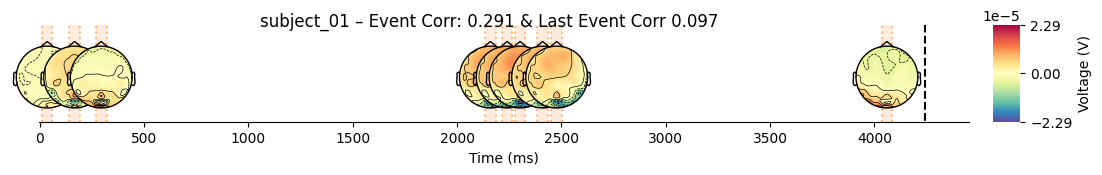

<Figure size 1000x400 with 0 Axes>

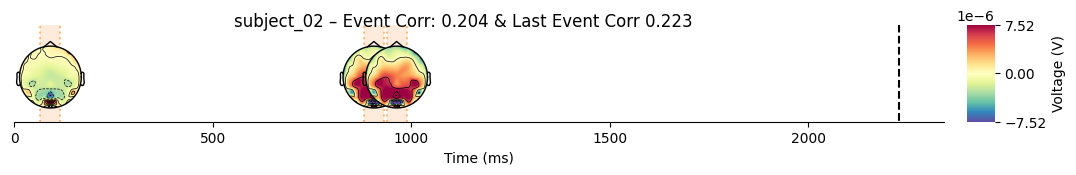

<Figure size 1000x400 with 0 Axes>

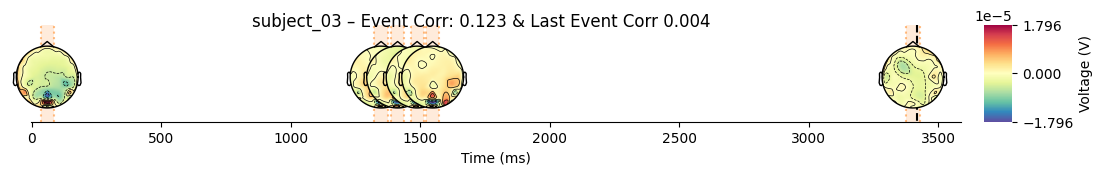

<Figure size 1000x400 with 0 Axes>

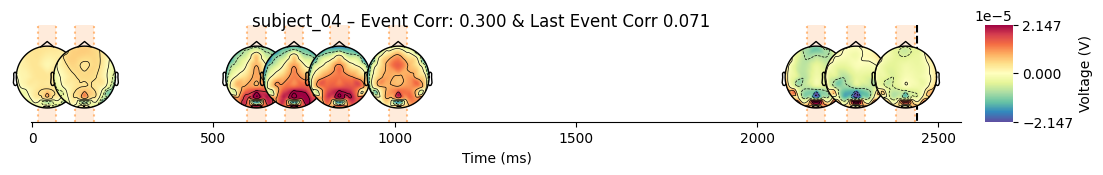

<Figure size 1000x400 with 0 Axes>

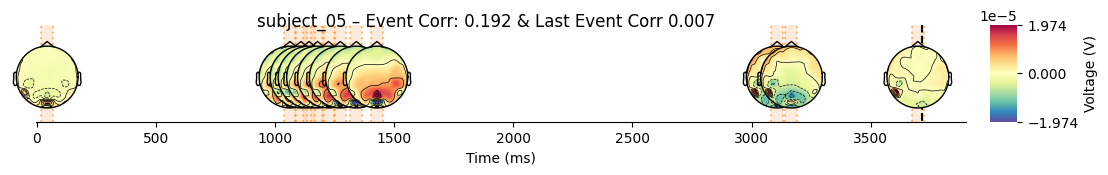

<Figure size 1000x400 with 0 Axes>

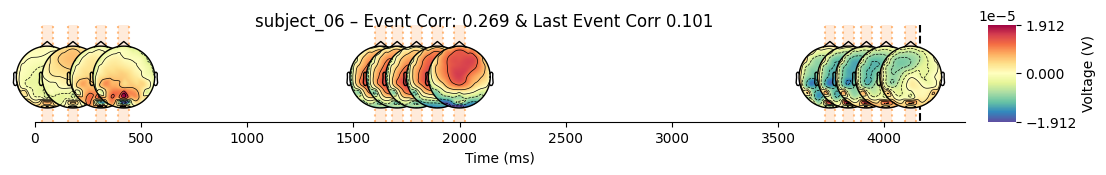

<Figure size 1000x400 with 0 Axes>

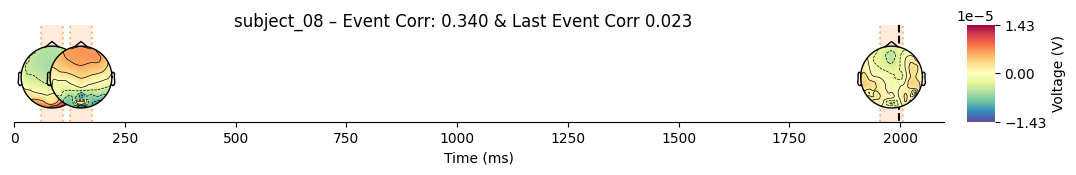

<Figure size 1000x400 with 0 Axes>

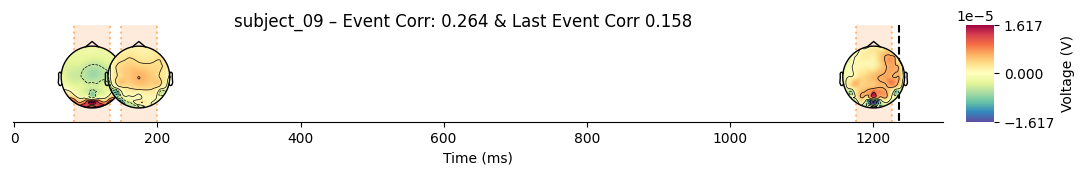

<Figure size 1000x400 with 0 Axes>

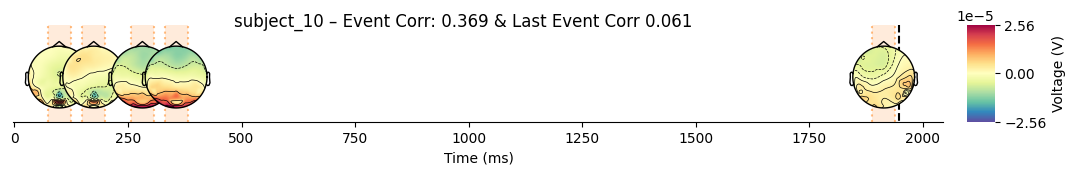

<Figure size 1000x400 with 0 Axes>

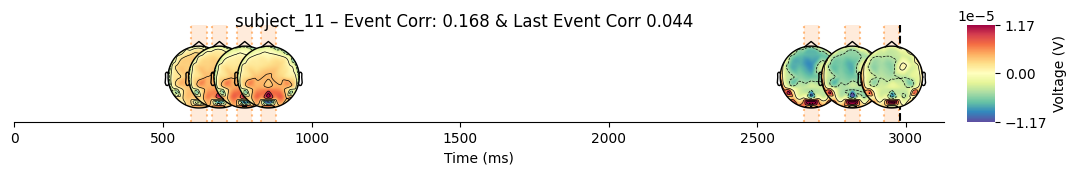

<Figure size 1000x400 with 0 Axes>

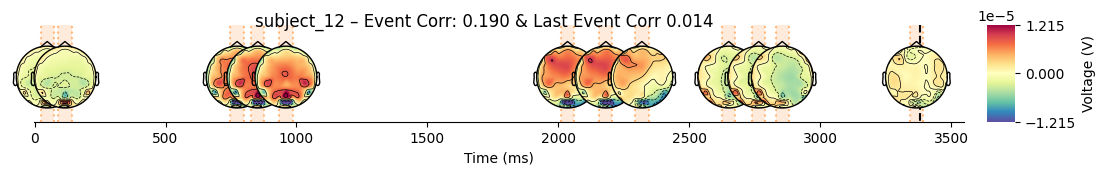

<Figure size 1000x400 with 0 Axes>

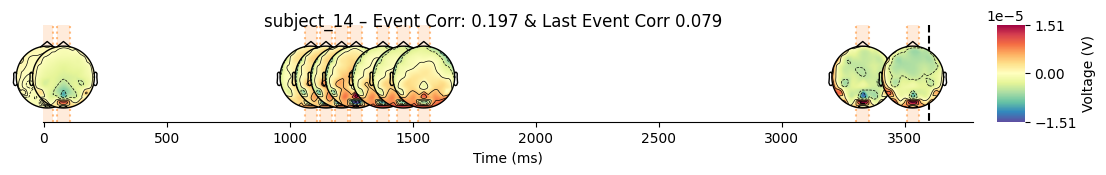

<Figure size 1000x400 with 0 Axes>

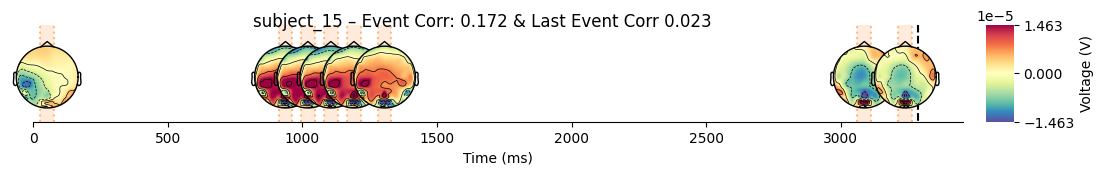

<Figure size 1000x400 with 0 Axes>

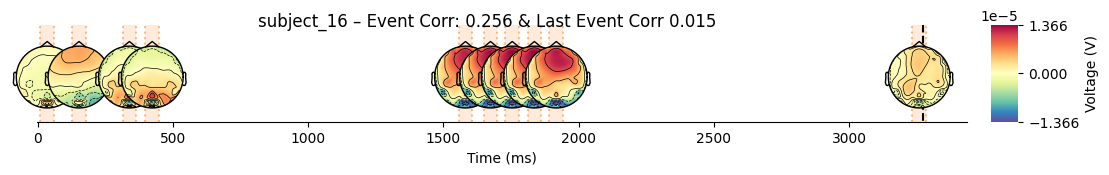

<Figure size 1000x400 with 0 Axes>

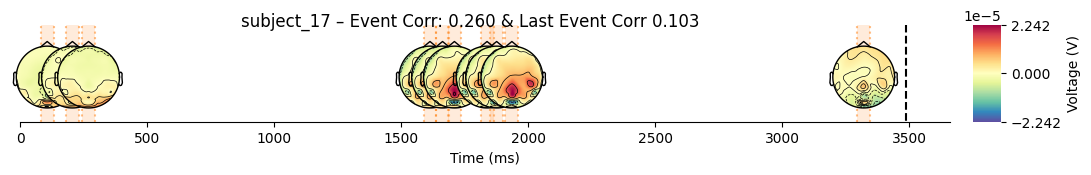

<Figure size 1000x400 with 0 Axes>

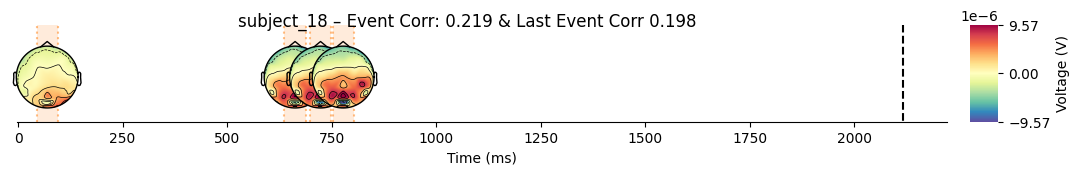

<Figure size 1000x400 with 0 Axes>

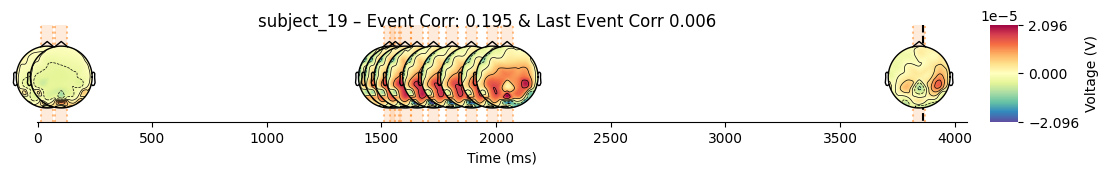

<Figure size 1000x400 with 0 Axes>

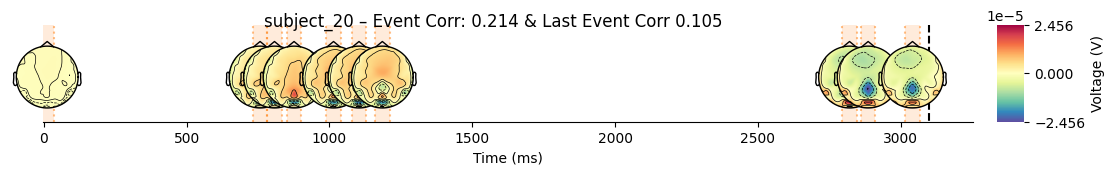

<Figure size 1000x400 with 0 Axes>

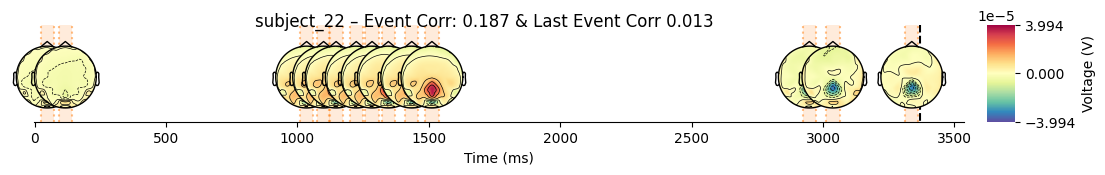

<Figure size 1000x400 with 0 Axes>

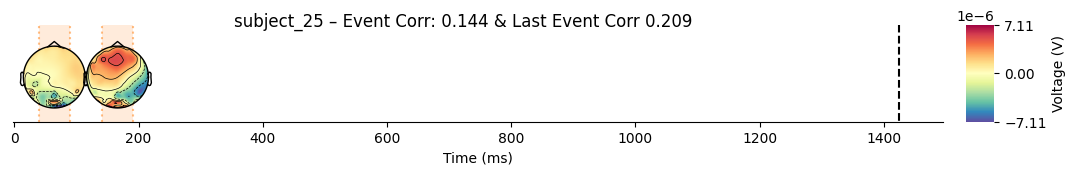

In [6]:
epoch_data = models_dict["subject_01"]["epoch_data"]

# Get the list of channels from the xarray
channel_names = epoch_data.channels.values.tolist()

# Create a MNE montage 
montage = mne.channels.make_standard_montage('biosemi64')

# Extract 2D coordinates (x, y) for each channel
positions = np.array([montage.get_positions()['ch_pos'][ch][:2] for ch in channel_names])

# --- Spatial correlation analysis across all subjects ---

# Compute per-event spatial correlation values for each subject
maps_corr_dict = compute_subjectwise_event_correlations(models_dict)

# Compute the mean correlation across events for each subject
mean_corr_across_events = {
    subject: np.mean(event_corrs)
    for subject, event_corrs in maps_corr_dict.items()
}

for subject in models_dict:
    model_info = models_dict[subject]
    model = model_info["model"]
    epoch_data = model_info["epoch_data"]
    init = model_info["init"]
    mean_corr = mean_corr_across_events[subject]
    last_event_corr = maps_corr_dict[subject][-1]

    # Create and show figure
    plt.figure(figsize=(10, 4))
    hmp.visu.plot_topo_timecourse(epoch_data, model,
                                  positions, init,
                                  magnify=1, sensors=False,
                                  as_time=True)
    plt.suptitle(f"{subject} – Event Corr: {mean_corr:.3f} & Last Event Corr {last_event_corr:.3f}")